In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv('../data/telco_cleaned.csv')
df.shape

(7043, 25)

In [3]:
df = df.drop(columns=['Churn Label'])

cluster_features = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV',
                     'Multiple Lines', 'Internet Service_Fiber optic', 'Internet Service_No',
                     'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
                     'Streaming TV', 'Streaming Movies',
                     'Contract_One year', 'Contract_Two year']

X_cluster = df[cluster_features]
X_cluster.shape

(7043, 15)

In [4]:
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)
X_cluster_scaled.shape

(7043, 15)

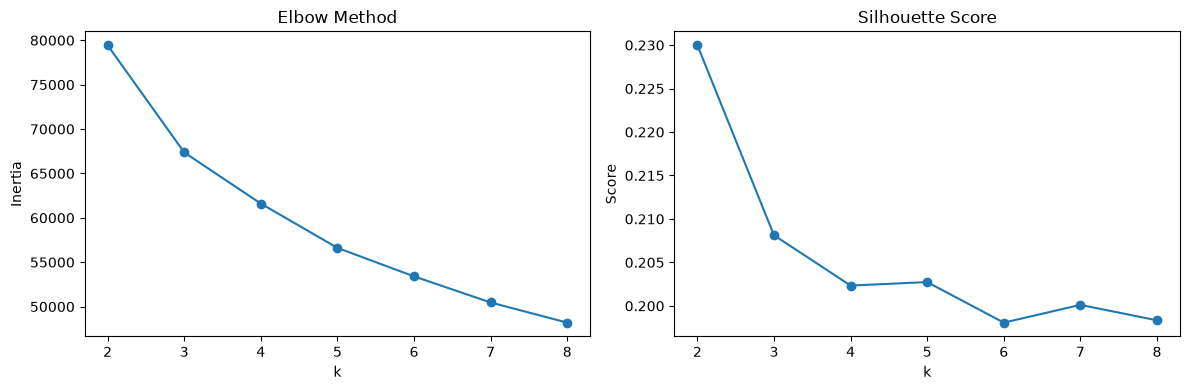

In [5]:
inertias = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(k_range, inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouette_scores, marker='o')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')
plt.tight_layout()
plt.show()

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_cluster_scaled)

df['KMeans_Cluster'].value_counts()

KMeans_Cluster
1    3240
2    2272
0    1531
Name: count, dtype: int64